# No PCA

## Import + data loading 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch
sns.set_style("whitegrid")

# Parameters
filter=True

# LOAD DATA
GITHUB_BASE = "https://raw.githubusercontent.com/AyaanTigdikar/Capstone/main/MASTER/"
master = pd.read_csv(f"{GITHUB_BASE}Master.csv").drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Master: {len(master)} obs, {master['Country Code'].nunique()} countries")
# PREPARE PANEL
df = master[(master['Year'] >= 1995) & (master['Year'] <= 2019)].dropna(subset=['Economic Complexity Index']).copy()
df = df.sort_values(['Country Code', 'Year'])
resource_rich_countries = master[master['Year'] == 1995][
    master[master['Year'] == 1995]['Total natural resources rents (% of GDP)'] >= 5
]['Country Code'].unique()
if filter:
    df = df[df['Country Code'].isin(resource_rich_countries)]
df['Resource_Rich'] = df['Country Code'].isin(resource_rich_countries).astype(int)

df['L1_ECI'] = df.groupby('Country Code')['Economic Complexity Index'].shift(1) # ECI lag

# Drop rows with NaNs created by lagging
df = df.dropna()

Master: 3150 obs, 126 countries


## Model

In [2]:
# Interactions
df['HCI_x_ProductionValue'] = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index'] * df['Total_Production_Value']


# FEATURES (without PCA, not time-varying)
base_features = [
    'Human capital index', 'Rule of law index', 'Political stability — estimate',
    'Trade (% of GDP)', 'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)', 'Landlocked',
    'Urban population (% of total population)', 'Government revenue',
    'Capital depreciation rate', 'Use of IMF credit (DOD, current US$)', 'Services',
    'Real interest rate (%)', 'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)', 'Adjusted savings: gross savings (% of GNI)',
    'L1_ECI'
]
nat_int = [
    'Total natural resources rents (% of GDP)',
    'Oil rents (% of GDP)',
    'Mineral rents (% of GDP)',
    'Natural gas rents (% of GDP)'
]

all_features = base_features + ['Resource_Rich','HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue']

print(f"Total features: {len(all_features)} (17 base + 1 group + 2 interactions)")

y = df['Economic Complexity Index'].values
X = df[all_features].copy()
years = df['Year'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

# Split
train_mask = years <= 2014
X_train, X_test = X_scaled[train_mask], X_scaled[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Train
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=tscv).fit(X_train, y_train)
elastic = ElasticNetCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
#rf = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=10, 
#                           random_state=42, n_jobs=-1, oob_score=True).fit(X_train, y_train)

models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic}

print("All models trained")

# Collect importance
all_importance = pd.DataFrame({'Feature': all_features})
feature_signs = pd.DataFrame({'Feature': all_features})
for name, model in models.items():
    if name in ['LASSO', 'Ridge', 'Elastic Net']:
        all_importance[name] = np.abs(model.coef_)
        feature_signs[name] = np.sign(model.coef_)
    else:
        all_importance[name] = model.feature_importances_
        feature_signs[name] = 1.0
all_importance['Average'] = all_importance[['LASSO', 'Ridge', 'Elastic Net']].mean(axis=1)

# Performance
perf = []
for name, model in models.items():
    perf.append({
        'Model': name,
        'Test_R2': model.score(X_test, y_test),
        'Train_R2': model.score(X_train, y_train)
    })
perf_df = pd.DataFrame(perf).sort_values('Test_R2', ascending=False)

print("Importance collected from all models")

Total features: 21 (17 base + 1 group + 2 interactions)
All models trained
Importance collected from all models


In [3]:
all_features

['Human capital index',
 'Rule of law index',
 'Political stability — estimate',
 'Trade (% of GDP)',
 'Gross fixed capital formation, all, Constant prices, Percent of GDP',
 'Share of investment in GDP',
 'Domestic credit to private sector (% of GDP)',
 'Landlocked',
 'Urban population (% of total population)',
 'Government revenue',
 'Capital depreciation rate',
 'Use of IMF credit (DOD, current US$)',
 'Services',
 'Real interest rate (%)',
 'Inflation, consumer prices (annual %)',
 'Access to electricity (% of population)',
 'Adjusted savings: gross savings (% of GNI)',
 'L1_ECI',
 'Resource_Rich',
 'HCI_x_ProductionValue',
 'RuleOfLaw_x_ProductionValue']

## Graphics

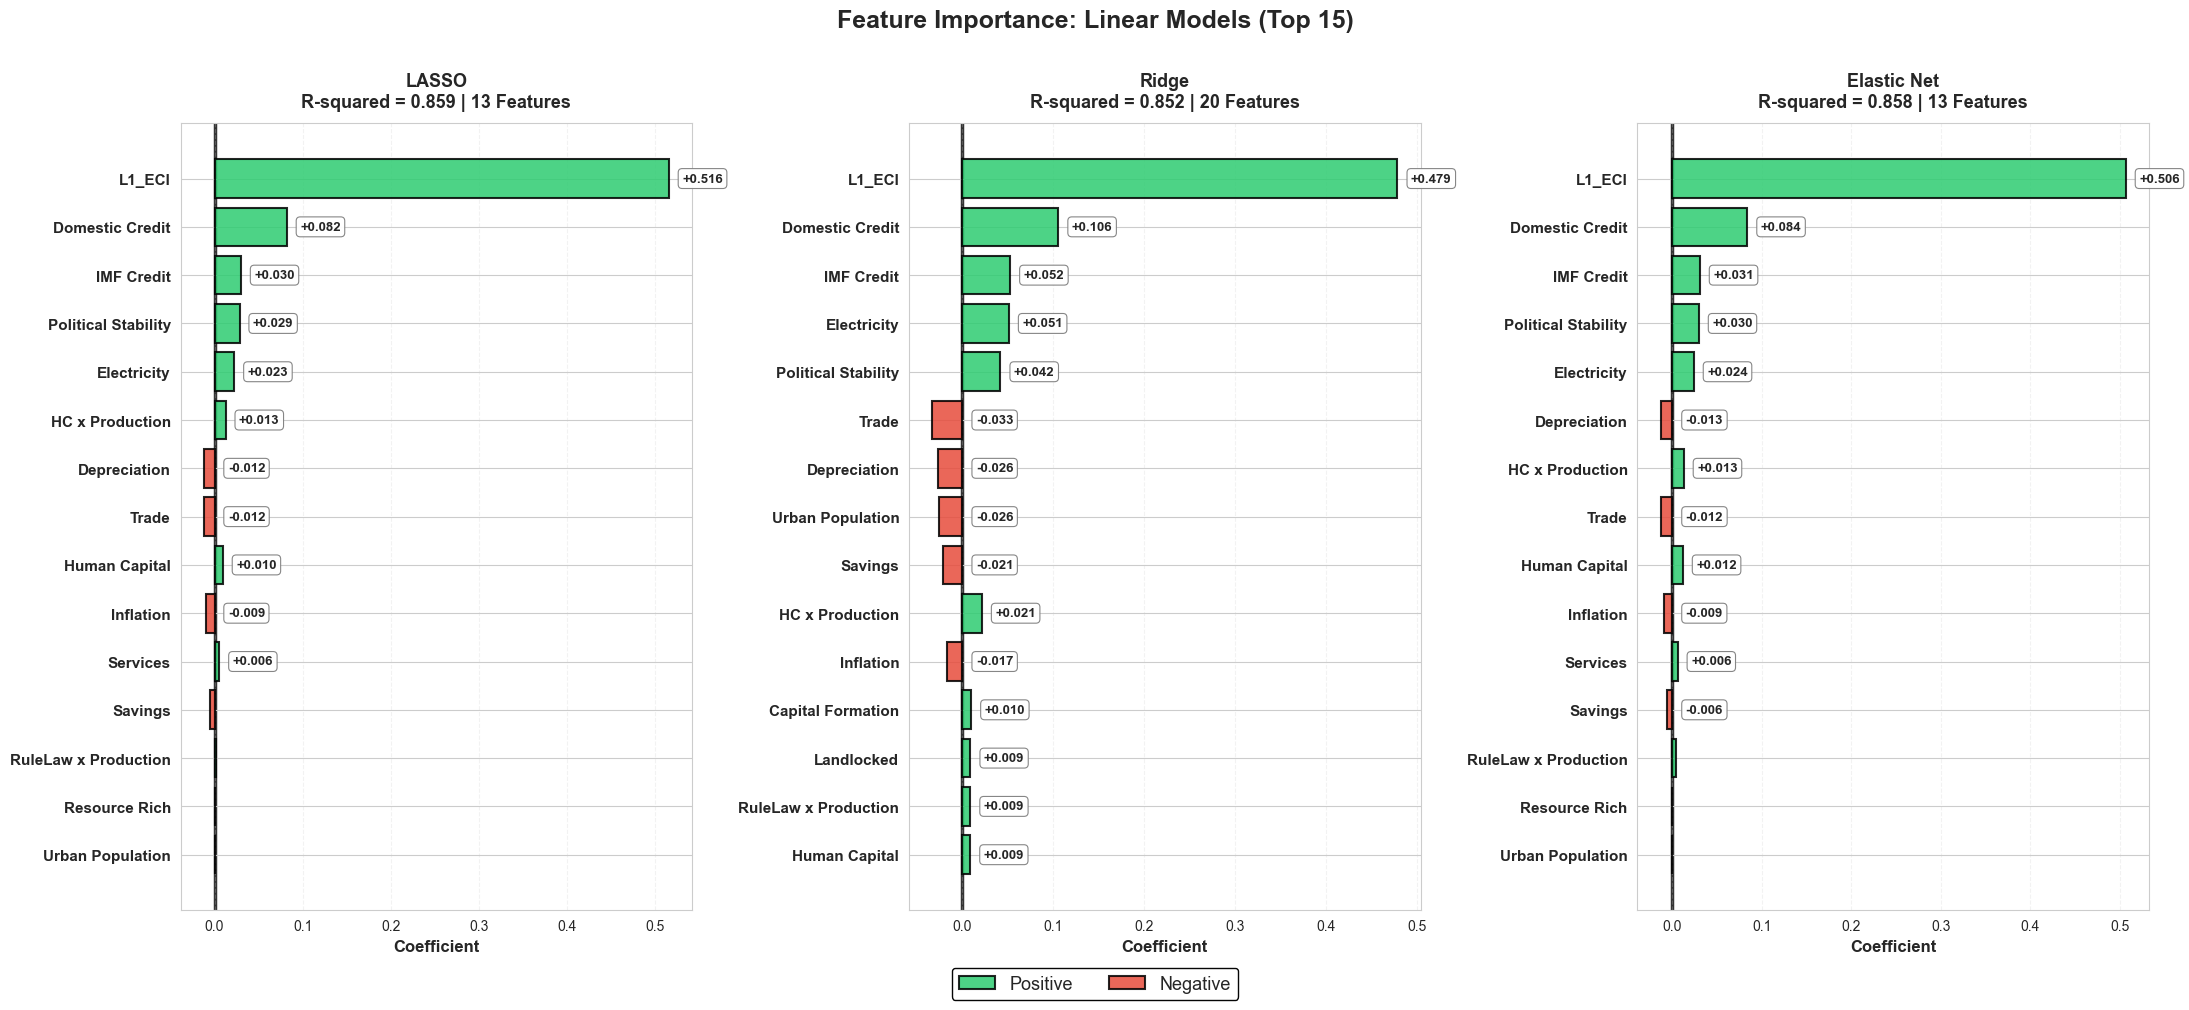


[6/6] Model agreement plot...


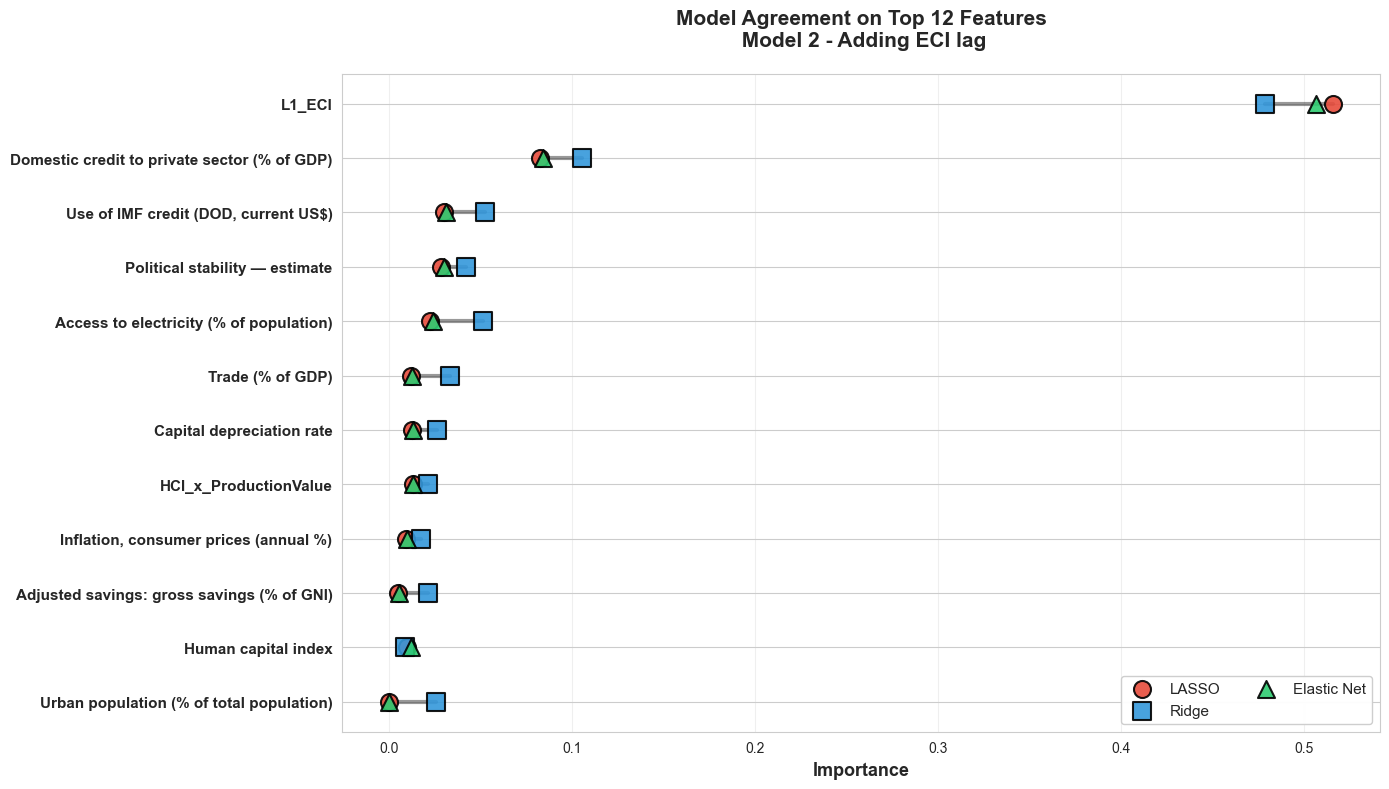

In [4]:
# Name mapping for shorter labels
name_mapping = {
    'Human capital index': 'Human Capital',
    'Rule of law index': 'Rule of Law',
    'Political stability — estimate': 'Political Stability',
    'Trade (% of GDP)': 'Trade',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP': 'Capital Formation',
    'Share of investment in GDP': 'Investment Share',
    'Domestic credit to private sector (% of GDP)': 'Domestic Credit',
    'Landlocked': 'Landlocked',
    'Urban population (% of total population)': 'Urban Population',
    'Government revenue': 'Gov Revenue',
    'Capital depreciation rate': 'Depreciation',
    'Use of IMF credit (DOD, current US$)': 'IMF Credit',
    'Services': 'Services',
    'Real interest rate (%)': 'Interest Rate',
    'Inflation, consumer prices (annual %)': 'Inflation',
    'Access to electricity (% of population)': 'Electricity',
    'Adjusted savings: gross savings (% of GNI)': 'Savings',
    'Total_Production_Value': 'Production Value',
    'Resource_Rich': 'Resource Rich',
    'HCI_x_ProductionValue': 'HC x Production',
    'RuleOfLaw_x_ProductionValue': 'RuleLaw x Production',
    'GFCF_x_ProductionValue': 'GFCF x Production'
}

def shorten_name(name):
    return name_mapping.get(name, name[:22])

# ============================================================================
# VISUALIZATION 1: 3-Panel Comparison (LASSO, Ridge, Elastic Net)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 10))

for idx, model_name in enumerate(['LASSO', 'Ridge', 'Elastic Net']):
    ax = axes[idx]
    
    # Get top 15 with signs
    signed_vals = models[model_name].coef_
    abs_vals = np.abs(signed_vals)
    top_15_idx = np.argsort(abs_vals)[::-1][:15]
    
    top_15_features = [all_features[i] for i in top_15_idx]
    top_15_values = signed_vals[top_15_idx]
    
    # Color by sign
    colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in top_15_values]
    labels = [shorten_name(f) for f in top_15_features]
    
    y_pos = np.arange(len(top_15_features))
    bars = ax.barh(y_pos, top_15_values, color=colors, alpha=0.85, 
                  edgecolor='black', linewidth=1.5)
    
    ax.axvline(0, color='black', linewidth=2.5, alpha=0.8, zorder=0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    
    test_r2 = perf_df[perf_df['Model'] == model_name]['Test_R2'].values[0]
    n_features = np.sum(abs_vals != 0)
    ax.set_title(f'{model_name}\nR-squared = {test_r2:.3f} | {n_features} Features', 
                fontsize=13, fontweight='bold', pad=12)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    
    # Add values
    for i, val in enumerate(top_15_values):
        if abs(val) > 0.005:
            if val > 0:
                # Positive: show from right of bar
                x_offset = abs(val) + 0.015
            else:
                # Negative: show at zero line
                x_offset = 0.015
            
            ha = 'left'  # Always left-align
            ax.text(x_offset, i, f'{val:+.3f}', 
                va='center', ha=ha, fontsize=9.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                            alpha=0.95, edgecolor='gray', linewidth=0.8))

fig.legend(handles=[
    Patch(facecolor='#2ECC71', label='Positive', alpha=0.85, edgecolor='black', linewidth=1.5),
    Patch(facecolor='#E74C3C', label='Negative', alpha=0.85, edgecolor='black', linewidth=1.5)
], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=13, 
   framealpha=0.98, edgecolor='black', fancybox=True)

plt.suptitle('Feature Importance: Linear Models (Top 15)', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])

# dpi=300 is standard for print; dpi=600 is ultra-high res
plt.savefig(r'..\figures\coefs_model2_resource_rich.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# VISUALIZATION 6: Model Agreement with Ranges

print("\n[6/6] Model agreement plot...")
fig, ax = plt.subplots(figsize=(14, 8))
top_12 = all_importance.sort_values('Average', ascending=False).head(12)

# For each feature, plot model values and range
y_pos = np.arange(len(top_12))

for i, (_, row) in enumerate(top_12.iterrows()):
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net']]
    
    # Plot range line
    ax.plot([min(vals), max(vals)], [i, i], 'k-', alpha=0.4, linewidth=3, zorder=1)
    
    # Plot model points
    ax.scatter(row['LASSO'], i, marker='o', s=150, alpha=0.9, 
              color='#E74C3C', edgecolor='black', linewidth=1.5, zorder=3, label='LASSO' if i==0 else '')
    ax.scatter(row['Ridge'], i, marker='s', s=150, alpha=0.9, 
              color='#3498DB', edgecolor='black', linewidth=1.5, zorder=3, label='Ridge' if i==0 else '')
    ax.scatter(row['Elastic Net'], i, marker='^', s=150, alpha=0.9, 
              color='#2ECC71', edgecolor='black', linewidth=1.5, zorder=3, label='Elastic Net' if i==0 else '')
    #ax.scatter(row['Random Forest'], i, marker='D', s=150, alpha=0.9, 
    #          color='#F39C12', edgecolor='black', linewidth=1.5, zorder=3, label='Random Forest' if i==0 else '')

ax.set_yticks(y_pos)
ax.set_yticklabels([f[:45] for f in top_12['Feature']], fontsize=11, fontweight='bold')
ax.set_xlabel('Importance', fontsize=13, fontweight='bold')
ax.set_title('Model Agreement on Top 12 Features\n Model 2 - Adding ECI lag', 
            fontsize=15, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend(fontsize=11, loc='lower right', framealpha=0.95, ncol=2)
ax.grid(axis='x', alpha=0.3)

plt.savefig(r'..\figures\ML_model_2_resource_rich.png', dpi=300, bbox_inches='tight')
plt.savefig(r'..\figures\ML_model_2_resource_rich.pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()